# How has GenAI impacted ICT Job Postings?

## 1. ICT Professionals Vacancies Over Time (Australia)

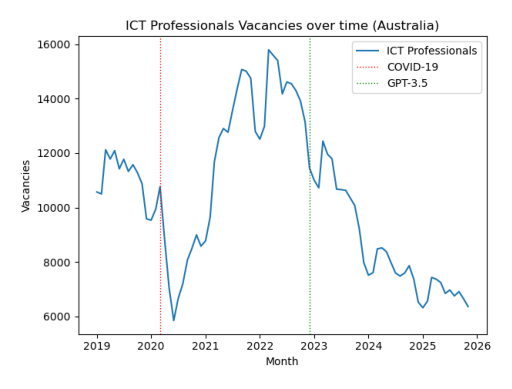

In [30]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "outputs/images/ICT Professionals.png" 
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

There is obviously a decline in the number of job postings in ICT since GenAI started to become mainstream (Nov 2022, Release of GPT 3.5).

**But is GenAI the (sole) cause of the decline?**

To answer this, we need to compare the change in job postings of ICT to other professions.

In [31]:
import pandas as pd

# Load the  vacancy data from CSV
df = pd.read_csv('outputs/dataframes/aus_vacancy.csv')
df = df.drop("Unnamed: 0", axis=1)

# Identify columns representing dates (formatted as 'Month-Year')
date_cols = [col for col in df.columns if '-' in col]

df.head(5)

,ANZSCO_TITLE,ANZSCO_CODE,Jan-19,Feb-19,Mar-19,Apr-19,May-19,Jun-19,Jul-19,Aug-19,...,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25
0,TOTAL,0,165363,165429,185974,174667,176608,169588,177768,175656,...,192841,215338,204042,206099,201701,210416,208051,214332,215499,209716
1,MANAGERS,1,21384,21744,24286,22888,22780,21810,22467,22145,...,23260,26155,24934,25301,24725,25513,25059,25396,25140,23969
2,"Chief Executives, Managing Directors & Legisla...",11,738,733,807,804,845,811,840,803,...,956,1021,1011,1051,1047,1080,1053,1044,1040,1005
3,Farmers and Farm Managers,12,109,122,149,132,127,123,136,142,...,173,193,187,197,187,199,198,200,190,178
4,"Hospitality, Retail and Service Managers",14,5142,5273,5841,5344,5223,4974,5070,5149,...,7159,8012,7456,7548,7365,7613,7531,7626,7582,7097


In [32]:
# Calculating percentage change compared to Nov-2022  

latest_month = date_cols[-1]

df['percent_change'] = ((df[latest_month] - df['Nov-22']) / df['Nov-22']) * 100
df.sort_values(by="percent_change").head(5)

,ANZSCO_TITLE,ANZSCO_CODE,Jan-19,Feb-19,Mar-19,Apr-19,May-19,Jun-19,Jul-19,Aug-19,...,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,percent_change
55,Food Preparation Assistants,85,901,882,999,940,942,843,904,955,...,940,886,904,859,904,919,1009,1069,1063,-66.905355
33,Hospitality Workers,43,3648,3511,4001,3724,3779,3586,4038,4447,...,3251,3103,3117,2987,3139,3272,3642,3871,3784,-66.214286
11,ICT Professionals,26,10571,10500,12123,11785,12092,11423,11776,11329,...,7430,7365,7242,6840,6968,6750,6907,6651,6359,-51.646263
45,Sales Support Workers,63,1229,1163,1319,1153,1177,1063,1038,936,...,1234,1137,1155,1126,1209,1189,1282,1261,1223,-42.555190
34,Protective Service Workers,44,735,748,811,775,759,727,728,693,...,926,891,919,864,908,913,948,944,928,-41.927409


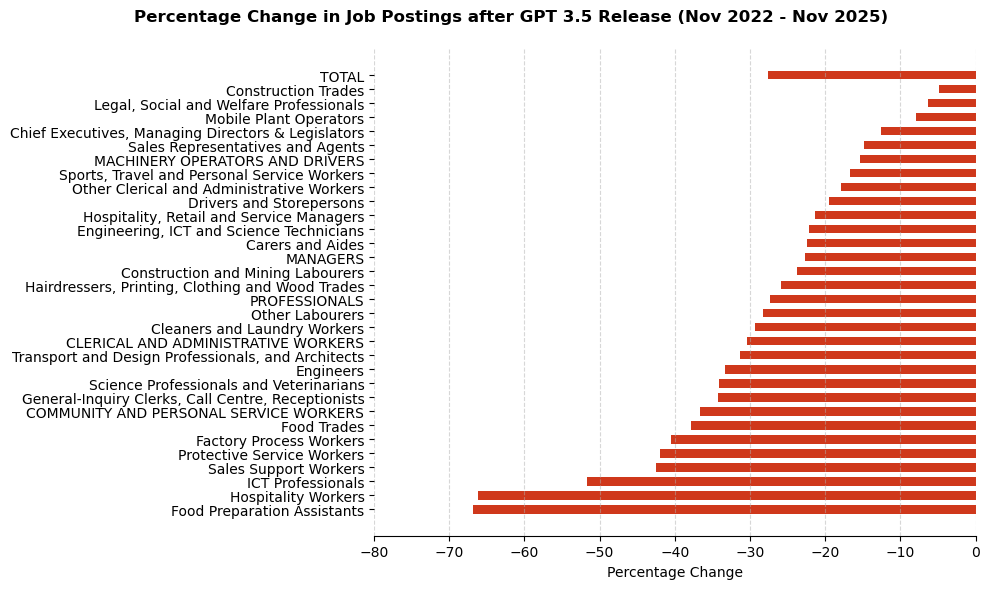

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Separate and sort data
code_0 = df[df['ANZSCO_CODE'] == "0"]
top5 = df[:5]
others = df[df['ANZSCO_CODE'] != "0"][5::2].sort_values('percent_change', ascending=True)
df_plot = pd.concat([top5, others, code_0])

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['ANZSCO_TITLE'], df_plot['percent_change'], color='#CF381B', height=0.6)

# Style
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(-80, 0)
    
plt.title('Percentage Change in Job Postings after GPT 3.5 Release (Nov 2022 - Nov 2025)', loc='left', fontweight='bold', pad=20, x=-0.4)
plt.xlabel('Percentage Change')
plt.tight_layout()
plt.show()